# 📘 Cambios de Base — Conceptos Fundamentales

---

## 🎯 Objetivos de aprendizaje

Al finalizar esta lección serás capaz de:

- Identificar qué es una **base** y cómo se expresan las coordenadas de un vector respecto a ella.
- Construir la **matriz de cambio de base** $P$ a partir de los vectores de la nueva base.
- Convertir coordenadas entre bases usando $P$ y $P^{-1}$.
- Calcular la **representación matricial** de una transformación lineal en una base diferente.
- Reconocer la relación entre **matrices similares** y el cambio de base.

---

> 💡 **Motivación:** Imagina que describes la posición de un punto en el mapa.
> Puedes usar coordenadas geográficas (latitud/longitud) o coordenadas cartesianas locales.
> *El punto no cambia* — solo cambia el sistema de referencia. Los cambios de base son exactamente eso:
> el mismo objeto matemático visto desde diferentes perspectivas.

## 🟦 1. ¿Qué es una base?

Una **base** de $\mathbb{R}^n$ es un conjunto de $n$ vectores linealmente independientes que
generan todo el espacio. La base **estándar** de $\mathbb{R}^2$ es $\mathcal{E} = \{\mathbf{e}_1, \mathbf{e}_2\} = \{(1,0),(0,1)\}$.

### Coordenadas relativas a una base

Si $\mathcal{B} = \{\mathbf{b}_1, \mathbf{b}_2\}$ es una base de $\mathbb{R}^2$, entonces para todo $\mathbf{v}$
existe un **único** par de escalares $(c_1, c_2)$ tal que:

$$\mathbf{v} = c_1 \mathbf{b}_1 + c_2 \mathbf{b}_2$$

El vector $(c_1, c_2)$ se llama el **vector de coordenadas** de $\mathbf{v}$ en la base $\mathcal{B}$, y se escribe:

$$[\mathbf{v}]_{\mathcal{B}} = \begin{pmatrix} c_1 \\ c_2 \end{pmatrix}$$

**Ejemplo concreto:** Sea $\mathcal{B} = \{(1,1), (-1,1)\}$ y $\mathbf{v} = (3,1)$.
Buscamos $c_1, c_2$ tal que:

$$c_1(1,1) + c_2(-1,1) = (3,1) \quad\Rightarrow\quad c_1 - c_2 = 3, \quad c_1 + c_2 = 1$$

Resolviendo: $c_1 = 2$, $c_2 = -1$. Entonces $[\mathbf{v}]_{\mathcal{B}} = (2,-1)^\top$.

In [1]:
import numpy as np

# Definimos la base B = {b1, b2}
b1 = np.array([1, 1])
b2 = np.array([-1, 1])

# El vector que queremos expresar en la base B
v = np.array([3, 1])

# La matriz P tiene como columnas los vectores de la base B
P = np.column_stack([b1, b2])
print("Matriz P (columnas = vectores de B):")
print(P)

# Encontrar coordenadas: resolver P @ coords = v
coords = np.linalg.solve(P, v)
print(f"\nCoordenadas de v={v} en la base B:")
print(f"  [v]_B = {coords}")

# Verificación: reconstruir v a partir de sus coordenadas en B
v_reconstruido = coords[0] * b1 + coords[1] * b2
print(f"\nVerificación: {coords[0]}*{b1} + {coords[1]}*{b2} = {v_reconstruido}")
print(f"¿Coincide con v original? {np.allclose(v_reconstruido, v)}")

Matriz P (columnas = vectores de B):
[[ 1 -1]
 [ 1  1]]

Coordenadas de v=[3 1] en la base B:
  [v]_B = [ 2. -1.]

Verificación: 2.0*[1 1] + -1.0*[-1  1] = [3. 1.]
¿Coincide con v original? True


## 🟦 2. La Matriz de Cambio de Base $P$

La **matriz de cambio de base** $P$ (de $\mathcal{B}$ a $\mathcal{E}$) se construye colocando los
vectores de la nueva base $\mathcal{B}$ como **columnas**, expresados en coordenadas estándar:

$$P = \begin{bmatrix} \mathbf{b}_1 & \mathbf{b}_2 & \cdots & \mathbf{b}_n \end{bmatrix}$$

Esta matriz tiene una propiedad fundamental: **siempre es invertible** (porque los vectores de $\mathcal{B}$ son l.i.).

### ¿Qué hace cada operación?

| Operación | Significado |
|:---:|:---|
| $\mathbf{v} = P \cdot [\mathbf{v}]_\mathcal{B}$ | Convierte de coordenadas $\mathcal{B}$ → estándar |
| $[\mathbf{v}]_\mathcal{B} = P^{-1} \cdot \mathbf{v}$ | Convierte de coordenadas estándar → $\mathcal{B}$ |

### Interpretación geométrica

Las columnas de $P$ son los **nuevos ejes** del sistema $\mathcal{B}$, expresados en el lenguaje del
sistema estándar. Multiplicar por $P$ es como *traducir* desde el idioma $\mathcal{B}$ al idioma estándar.

```{admonition} 👉 Regla mnemotécnica
:class: tip
Columnas de $P$ = Vectores de la nueva base $\mathcal{B}$ en coordenadas estándar.
```

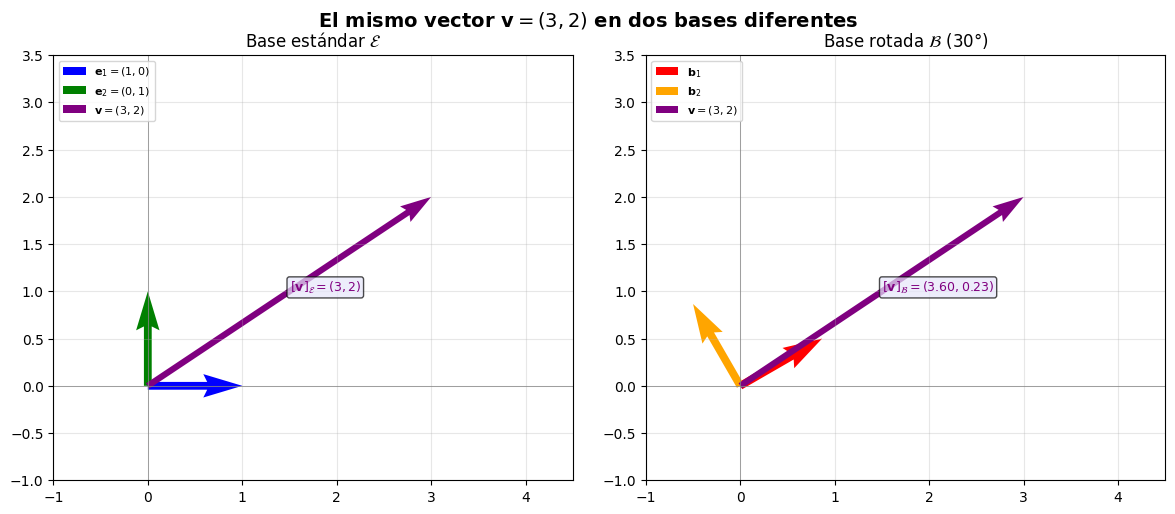

Coordenadas estándar: [3 2]
Coordenadas en base B (30°): [3.5981, 0.2321]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('El mismo vector $\\mathbf{v}=(3,2)$ en dos bases diferentes', fontsize=14, fontweight='bold')

theta = np.radians(30)  # Rotación de 30 grados
b1 = np.array([np.cos(theta), np.sin(theta)])
b2 = np.array([-np.sin(theta), np.cos(theta)])
P = np.column_stack([b1, b2])
v = np.array([3, 2])
v_B = np.linalg.solve(P, v)

for ax, title, e1, e2, color1, color2, label1, label2, coords in [
    (axes[0], 'Base estándar $\\mathcal{E}$',
     np.array([1,0]), np.array([0,1]), 'blue', 'green',
     '$\\mathbf{e}_1=(1,0)$', '$\\mathbf{e}_2=(0,1)$', f'$[\\mathbf{{v}}]_{{\\mathcal{{E}}}}=({v[0]},{v[1]})$'),
    (axes[1], f'Base rotada $\\mathcal{{B}}$ (30°)',
     b1, b2, 'red', 'orange',
     f'$\\mathbf{{b}}_1$', f'$\\mathbf{{b}}_2$', f'$[\\mathbf{{v}}]_{{\\mathcal{{B}}}}=({v_B[0]:.2f},{v_B[1]:.2f})$')
]:
    ax.set_xlim(-1, 4.5); ax.set_ylim(-1, 3.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1, color=color1, width=0.015, label=label1)
    ax.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1, color=color2, width=0.015, label=label2)
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='purple', width=0.012, label=f'$\\mathbf{{v}}=(3,2)$')
    ax.annotate(coords, xy=(v[0]/2, v[1]/2), fontsize=9, color='purple',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lavender', alpha=0.7))
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/cambio_base_vis.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Coordenadas estándar: {v}")
print(f"Coordenadas en base B (30°): [{v_B[0]:.4f}, {v_B[1]:.4f}]")

## 🟩 3. Conversión de Coordenadas

Una vez construida $P$, la conversión entre sistemas de coordenadas es directa:

### De coordenadas $\mathcal{B}$ a coordenadas estándar

$$\mathbf{v} = P \cdot [\mathbf{v}]_\mathcal{B}$$

Las columnas de $P$ actúan como escala + dirección para reconstruir el vector.

### De coordenadas estándar a coordenadas $\mathcal{B}$

$$[\mathbf{v}]_\mathcal{B} = P^{-1} \cdot \mathbf{v}$$

La inversa "decodifica" las coordenadas estándar en el nuevo sistema.

### 📐 Ejemplo completo

Sea $\mathcal{B} = \left\{\begin{pmatrix}2\\1\end{pmatrix}, \begin{pmatrix}0\\3\end{pmatrix}\right\}$,
entonces $P = \begin{pmatrix}2 & 0\\1 & 3\end{pmatrix}$.

Para $\mathbf{v} = (4, 7)^\top$:

$$[\mathbf{v}]_\mathcal{B} = P^{-1}\mathbf{v} = \frac{1}{6}\begin{pmatrix}3 & 0\\-1 & 2\end{pmatrix}
\begin{pmatrix}4\\7\end{pmatrix} = \begin{pmatrix}2\\5/3\end{pmatrix}$$

> 🔍 Verifica: $2\cdot(2,1)^\top + \frac{5}{3}\cdot(0,3)^\top = (4,2)^\top + (0,5)^\top = (4,7)^\top$ ✓

In [3]:
import numpy as np

# Base B = {b1, b2}
b1 = np.array([2, 1])
b2 = np.array([0, 3])

# Construimos P
P = np.column_stack([b1, b2])
print("Matriz P:")
print(P)

# Calculamos P^{-1}
P_inv = np.linalg.inv(P)
print("\nMatriz P^{-1}:")
print(P_inv)
print(f"det(P) = {np.linalg.det(P):.2f}  (≠ 0, invertible ✓)")

# Vector en coordenadas estándar
v = np.array([4, 7])

# Convertir a coordenadas en B
v_B = P_inv @ v
print(f"\nVector en coordenadas estándar: v = {v}")
print(f"Coordenadas en base B: [v]_B = {v_B}")

# Verificación: reconstruir desde coordenadas en B
v_rec = P @ v_B
print(f"\nReconstrucción: P @ [v]_B = {v_rec}")
print(f"¿Igual a v original? {np.allclose(v_rec, v)}")

# Otro vector: dado en coordenadas B, pasarlo a estándar
v_B2 = np.array([3, -1])
v2 = P @ v_B2
print(f"\nSi [v]_B = {v_B2}, entonces v = P @ [v]_B = {v2}")

Matriz P:
[[2 0]
 [1 3]]

Matriz P^{-1}:
[[ 0.5         0.        ]
 [-0.16666667  0.33333333]]
det(P) = 6.00  (≠ 0, invertible ✓)

Vector en coordenadas estándar: v = [4 7]
Coordenadas en base B: [v]_B = [2.         1.66666667]

Reconstrucción: P @ [v]_B = [4. 7.]
¿Igual a v original? True

Si [v]_B = [ 3 -1], entonces v = P @ [v]_B = [6 0]


## 🟦 4. Cambio de Base en Transformaciones Lineales

Sea $T: \mathbb{R}^n \to \mathbb{R}^n$ una transformación lineal con matriz $A$ en la base estándar.
Si cambiamos a una base $\mathcal{B}$ (con matriz de cambio $P$), la transformación tiene
una **representación diferente** en la nueva base:

$$A_\mathcal{B} = P^{-1} A P$$

### ¿Por qué esta fórmula?

Para aplicar $T$ a un vector en coordenadas $\mathcal{B}$:

1. $P \cdot [\mathbf{v}]_\mathcal{B}$ → Convertir a coordenadas estándar.
2. $A \cdot (P \cdot [\mathbf{v}]_\mathcal{B})$ → Aplicar la transformación $T$.
3. $P^{-1} \cdot A P \cdot [\mathbf{v}]_\mathcal{B}$ → Convertir el resultado de vuelta a $\mathcal{B}$.

Es decir: $A_\mathcal{B} = P^{-1}AP$.

```{admonition} 🔑 Intuición
:class: important
La transformación $T$ es **la misma**. Lo que cambia es cómo la *describimos*. En una base adecuada,
la misma transformación puede tener una forma matricial mucho más simple (diagonal, por ejemplo).
```

In [4]:
import sympy as sp
import numpy as np

# Transformación T en base estándar
A = np.array([[3, 1],
              [0, 2]], dtype=float)

# Nueva base B = {(1,1), (1,0)}
b1 = np.array([1, 1])
b2 = np.array([1, 0])
P = np.column_stack([b1, b2])
P_inv = np.linalg.inv(P)

# Calcular A_B = P^{-1} A P
A_B = P_inv @ A @ P

print("Transformación T en base estándar A:")
print(A)
print("\nMatriz de cambio de base P:")
print(P)
print("\nRepresentación de T en base B:")
print("A_B = P^{-1} A P =")
print(np.round(A_B, 4))

# Verificación con sympy (exacta)
A_s = sp.Matrix([[3, 1], [0, 2]])
P_s = sp.Matrix([[1, 1], [1, 0]])
A_B_s = P_s.inv() * A_s * P_s
print("\nVerificación exacta (sympy):")
sp.pprint(A_B_s)

# Verificar que trace y determinante se preservan
print(f"\ntrace(A) = {np.trace(A):.2f},  trace(A_B) = {np.trace(A_B):.2f}")
print(f"det(A)   = {np.linalg.det(A):.2f},  det(A_B)   = {np.linalg.det(A_B):.2f}")

Transformación T en base estándar A:
[[3. 1.]
 [0. 2.]]

Matriz de cambio de base P:
[[1 1]
 [1 0]]

Representación de T en base B:
A_B = P^{-1} A P =
[[2. 0.]
 [2. 3.]]

Verificación exacta (sympy):
⎡2  0⎤
⎢    ⎥
⎣2  3⎦

trace(A) = 5.00,  trace(A_B) = 5.00
det(A)   = 6.00,  det(A_B)   = 6.00


## 🟩 5. Propiedades de la Matriz de Cambio de Base

| Propiedad | Enunciado |
|:---|:---|
| **Invertibilidad** | $P$ siempre es invertible (los vectores de base son l.i.) |
| **Identidad** | Si $\mathcal{B} = \mathcal{E}$, entonces $P = I$ y $P^{-1} = I$ |
| **Doble inversa** | $(P^{-1})^{-1} = P$ |
| **Composición** | Cambio de $\mathcal{B}_1$ a $\mathcal{B}_2$ a $\mathcal{B}_3$: matriz $P_3^{-1}P_2^{-1} \cdot P_2 P_1 = P_3^{-1}P_1$ |
| **Preserva operaciones** | $(AB)_\mathcal{B} = A_\mathcal{B} B_\mathcal{B}$ |
| **Preserva inversas** | Si $A$ es invertible, $(A^{-1})_\mathcal{B} = (A_\mathcal{B})^{-1}$ |

### Cambio de base entre dos bases no estándar

Si tienes una base $\mathcal{B}_1$ con matriz $P_1$ y una base $\mathcal{B}_2$ con matriz $P_2$
(ambas respecto a la base estándar), entonces la conversión de $\mathcal{B}_1$ a $\mathcal{B}_2$ es:

$$[\mathbf{v}]_{\mathcal{B}_2} = P_2^{-1} \cdot P_1 \cdot [\mathbf{v}]_{\mathcal{B}_1}$$

> 💡 **Truco:** Siempre puedes ir a la base estándar como **intermediario** entre dos bases.

A en base estándar:
[[0. 1.]
 [1. 0.]]

A_B en base B (b1, b2):
[[ 1.  0.]
 [-0. -1.]]

¡A_B es diagonal! La reflexión en la base {b1, b2} escala cada eje sin mezclarlos.


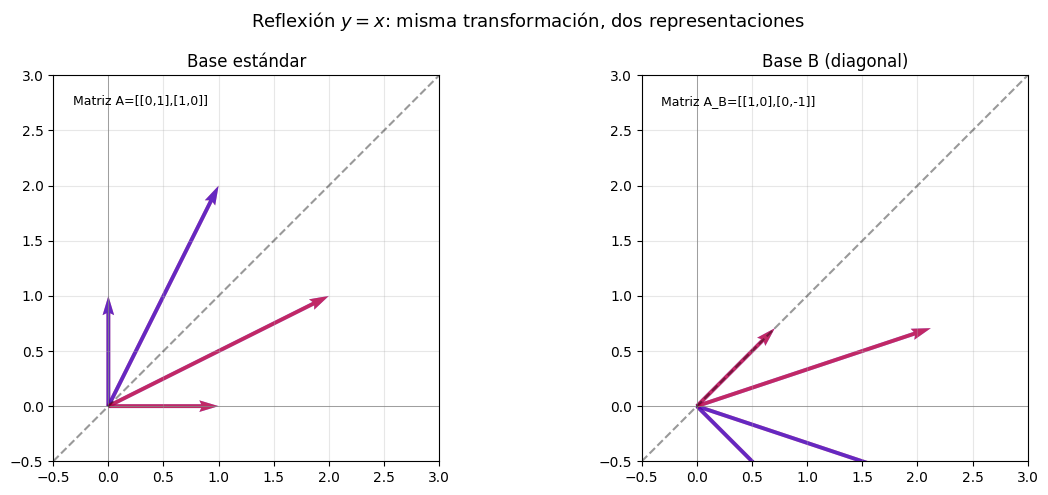

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Transformación T: reflexión sobre y=x, en base estándar A = [[0,1],[1,0]]
A = np.array([[0., 1.], [1., 0.]])

# Base B = {(1,1)/√2, (1,-1)/√2} — diagonaliza la reflexión
b1 = np.array([1, 1]) / np.sqrt(2)
b2 = np.array([1, -1]) / np.sqrt(2)
P = np.column_stack([b1, b2])
A_B = np.linalg.inv(P) @ A @ P

print("A en base estándar:")
print(np.round(A, 4))
print("\nA_B en base B (b1, b2):")
print(np.round(A_B, 4))
print("\n¡A_B es diagonal! La reflexión en la base {b1, b2} escala cada eje sin mezclarlos.")

# Visualizar T sobre varios vectores
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Reflexión $y=x$: misma transformación, dos representaciones', fontsize=13)

vecs = np.array([[1,0],[0,1],[2,1],[1,2]]).T
Tv = A @ vecs

for ax, title in zip(axes, ['Base estándar', 'Base B (diagonal)']):
    ax.set_xlim(-0.5, 3); ax.set_ylim(-0.5, 3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.plot([-0.5, 3], [-0.5, 3], 'k--', alpha=0.4, label='y=x')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.set_title(title)

for i in range(vecs.shape[1]):
    axes[0].quiver(0,0, vecs[0,i], vecs[1,i], angles='xy', scale_units='xy', scale=1,
                   color='blue', width=0.01, alpha=0.6)
    axes[0].quiver(0,0, Tv[0,i], Tv[1,i], angles='xy', scale_units='xy', scale=1,
                   color='red', width=0.01, alpha=0.6)

# En base B, mostrar como se ven los mismos vectores
vecs_B = np.linalg.inv(P) @ vecs
Tv_B = A_B @ vecs_B
for i in range(vecs_B.shape[1]):
    axes[1].quiver(0,0, vecs_B[0,i], vecs_B[1,i], angles='xy', scale_units='xy', scale=1,
                   color='blue', width=0.01, alpha=0.6)
    axes[1].quiver(0,0, Tv_B[0,i], Tv_B[1,i], angles='xy', scale_units='xy', scale=1,
                   color='red', width=0.01, alpha=0.6)

axes[0].text(0.05,0.95,'Matriz A=[[0,1],[1,0]]', transform=axes[0].transAxes, fontsize=9, verticalalignment='top')
axes[1].text(0.05,0.95,'Matriz A_B=[[1,0],[0,-1]]', transform=axes[1].transAxes, fontsize=9, verticalalignment='top')
plt.tight_layout(); plt.show()

## 🟥 6. Matrices Similares

Dos matrices cuadradas $A$ y $B$ son **similares** (notación: $A \sim B$) si existe una
matriz invertible $P$ tal que:

$$B = P^{-1}AP$$

El cambio de base muestra que $A$ y $A_\mathcal{B}$ son **siempre similares** — son la misma
transformación vista desde diferentes bases.

### 📐 Propiedades que comparten matrices similares

Si $A \sim B$, entonces:

| Propiedad | Valor compartido |
|:---|:---|
| **Determinante** | $\det(A) = \det(B)$ |
| **Traza** | $\text{tr}(A) = \text{tr}(B)$ |
| **Autovalores** | $A$ y $B$ tienen los mismos autovalores |
| **Rango** | $\text{rango}(A) = \text{rango}(B)$ |
| **Polinomio característico** | $\det(A - \lambda I) = \det(B - \lambda I)$ |

> ⚠️ **Cuidado:** El recíproco es falso — dos matrices con la misma traza y determinante
> **no necesariamente** son similares. (Ejemplo: $I$ y $\begin{pmatrix}1&1\\0&1\end{pmatrix}$ tienen
> los mismos autovalores pero no son similares.)

In [6]:
import numpy as np

# Dos matrices similares: A y A_B = P^{-1}AP
A = np.array([[4, 2],
              [1, 3]], dtype=float)

P = np.array([[1, 2],
              [1, 1]], dtype=float)

A_B = np.linalg.inv(P) @ A @ P

print("Matriz A:")
print(A)
print("\nMatriz similar A_B = P^{-1}AP:")
print(np.round(A_B, 6))

# Verificar propiedades compartidas
print("\n" + "="*40)
print("Propiedades compartidas:")
print(f"  tr(A)     = {np.trace(A):.4f}")
print(f"  tr(A_B)   = {np.trace(A_B):.4f}")
print(f"  det(A)    = {np.linalg.det(A):.4f}")
print(f"  det(A_B)  = {np.linalg.det(A_B):.4f}")

evals_A = np.sort(np.linalg.eigvals(A))
evals_B = np.sort(np.linalg.eigvals(A_B))
print(f"  λ(A)    = {np.round(evals_A, 4)}")
print(f"  λ(A_B)  = {np.round(evals_B, 4)}")

print(f"\n✅ Misma traza, determinante y autovalores — son matrices similares.")

Matriz A:
[[4. 2.]
 [1. 3.]]

Matriz similar A_B = P^{-1}AP:
[[2. 0.]
 [2. 5.]]

Propiedades compartidas:
  tr(A)     = 7.0000
  tr(A_B)   = 7.0000
  det(A)    = 10.0000
  det(A_B)  = 10.0000
  λ(A)    = [2. 5.]
  λ(A_B)  = [2. 5.]

✅ Misma traza, determinante y autovalores — son matrices similares.


## 🟨 7. Anticipo: La Base de Autovectores

Una pregunta natural: **¿cuál es la mejor base posible?**

Si $A$ tiene $n$ autovectores linealmente independientes $\{\mathbf{p}_1, \ldots, \mathbf{p}_n\}$
con autovalores $\{\lambda_1, \ldots, \lambda_n\}$, entonces usando $P = [\mathbf{p}_1 \mid \cdots \mid \mathbf{p}_n]$:

$$A_\mathcal{B} = P^{-1}AP = D = \begin{pmatrix} \lambda_1 & & \\ & \ddots & \\ & & \lambda_n \end{pmatrix}$$

¡La representación se vuelve **diagonal**! En la base de sus propios autovectores, una
transformación solo **escala** cada eje — no hay mezcla entre coordenadas.

Esto es el tema del **Capítulo 8: Diagonalización**. Por ahora, solo intuición:

> 🎯 Los autovectores son los vectores que **no cambian de dirección** bajo $T$.
> En ese sistema de referencia, $T$ se vuelve un simple escalado por los autovalores.

In [7]:
import numpy as np

# Matriz con dos autovectores independientes
A = np.array([[3., 1.],
              [0., 2.]])

# Encontrar autovalores y autovectores
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Autovalores de A:", eigenvalues)
print("Autovectores (columnas):\n", eigenvectors)

# La base de autovectores define P
P = eigenvectors
P_inv = np.linalg.inv(P)

# Calcular A en base de autovectores
D = P_inv @ A @ P
print("\nA en la base de autovectores (D = P^{-1}AP):")
print(np.round(D, 8))
print("\n¡D es DIAGONAL! Los autovalores aparecen en la diagonal.")

# Verificación: A = P D P^{-1}
A_rec = P @ D @ P_inv
print(f"\nVerificación A = P D P^{{-1}}: {np.allclose(A_rec, A)}")
print("A original:\n", A)
print("Reconstruida:\n", np.round(A_rec, 6))

Autovalores de A: [3. 2.]
Autovectores (columnas):
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]

A en la base de autovectores (D = P^{-1}AP):
[[3. 0.]
 [0. 2.]]

¡D es DIAGONAL! Los autovalores aparecen en la diagonal.

Verificación A = P D P^{-1}: True
A original:
 [[3. 1.]
 [0. 2.]]
Reconstruida:
 [[3. 1.]
 [0. 2.]]


## 📚 Resumen y Ejercicios Sugeridos

### 🎓 Lo que aprendiste en esta lección

| Concepto | Fórmula clave |
|:---|:---|
| Coordenadas en base $\mathcal{B}$ | $[\mathbf{v}]_\mathcal{B} = P^{-1}\mathbf{v}$ |
| Recuperar vector de coords | $\mathbf{v} = P[\mathbf{v}]_\mathcal{B}$ |
| Transformación en nueva base | $A_\mathcal{B} = P^{-1}AP$ |
| Matrices similares | $A \sim B \Leftrightarrow \exists P: B = P^{-1}AP$ |
| Mejor base posible | Base de autovectores → $A_\mathcal{B} = D$ (diagonal) |

### 🧩 Ejercicios para practicar

1. Dado $\mathcal{B} = \{(2,1)^\top, (1,2)^\top\}$, encuentra $[(5,4)^\top]_\mathcal{B}$.
2. Si $P = \begin{pmatrix}1&2\\3&4\end{pmatrix}$ y $[\mathbf{v}]_\mathcal{B} = (1,-1)^\top$, ¿cuánto es $\mathbf{v}$?
3. Sea $A = \begin{pmatrix}5&0\\0&3\end{pmatrix}$ y $P = \begin{pmatrix}1&1\\0&1\end{pmatrix}$. Calcula $P^{-1}AP$.
4. ¿Son similares $\begin{pmatrix}2&1\\0&2\end{pmatrix}$ y $\begin{pmatrix}2&0\\0&2\end{pmatrix}$? Argumenta.
5. Usa Python para verificar que la reflexión en $y=x$ es diagonal en la base $\{(1,1),(1,-1)\}$.

---

> 📘 *"El cambio de base es como traducir un poema a otro idioma. El significado no cambia,
> pero algunas ideas se expresan con mucha más elegancia en ciertas lenguas."*

👉 **Siguiente:** Ejemplos detallados → `ejemplos.ipynb`